In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
random_image = np.random.randint(0, 255, (255, 255))

In [5]:
random_image.shape

(255, 255)

In [6]:
plt.figure(figsize=(10, 10))

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

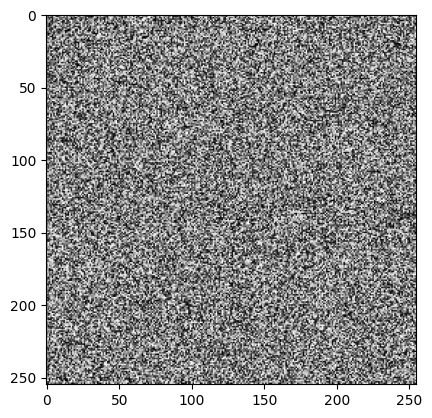

In [7]:
plt.imshow(random_image, cmap="gray", vmin=0, vmax=255)

In [8]:
plt.show()

## Scikit learn

In [9]:
import os
import numpy as np
import pandas as pd

from PIL import Image
from sklearn import ensemble
from sklearn import metrics
from sklearn import model_selection
# from tqdm import tqdm
# from tqdm.notebook import tqdm

In [32]:
def create_dataset(training_df, image_dir):
    images = []
    targets = []

    print(training_df.shape, image_dir)

    for index, row in training_df.iterrows():
        image_id = row["patientId"]
        image_path = os.path.join(image_dir, image_id)

        assert(os.path.exists(image_path + ".png"))
        
        image = Image.open(image_path + ".png")
        image = image.resize((256, 256), resample=Image.BILINEAR)
        image = np.array(image)
        image = image.ravel()

        images.append(image)
        targets.append(int(row["Target"]))

    images = np.array(images)

    print(image.shape)
    return images, targets

In [33]:
csv_path = '../../datasets/rsna-pneumonia-detection-challenge/train.csv'
image_path = '../../datasets/rsna-pneumonia-detection-challenge/train_png/'

In [34]:
assert os.path.exists(csv_path)

In [35]:
df = pd.read_csv(csv_path)

In [36]:
df.head(10)

,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1
5,00436515-870c-4b36-a041-de91049b9ab4,562.0,152.0,256.0,453.0,1
6,00569f44-917d-4c86-a842-81832af98c30,NaN,NaN,NaN,NaN,0
7,006cec2e-6ce2-4549-bffa-eadfcd1e9970,NaN,NaN,NaN,NaN,0
8,00704310-78a8-4b38-8475-49f4573b2dbb,323.0,577.0,160.0,104.0,1
9,00704310-78a8-4b38-8475-49f4573b2dbb,695.0,575.0,162.0,137.0,1


In [37]:
df["kfold"] = -1

In [38]:
df.head(10)

,patientId,x,y,width,height,Target,kfold
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0,-1
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0,-1
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0,-1
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0,-1
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1,-1
5,00436515-870c-4b36-a041-de91049b9ab4,562.0,152.0,256.0,453.0,1,-1
6,00569f44-917d-4c86-a842-81832af98c30,NaN,NaN,NaN,NaN,0,-1
7,006cec2e-6ce2-4549-bffa-eadfcd1e9970,NaN,NaN,NaN,NaN,0,-1
8,00704310-78a8-4b38-8475-49f4573b2dbb,323.0,577.0,160.0,104.0,1,-1
9,00704310-78a8-4b38-8475-49f4573b2dbb,695.0,575.0,162.0,137.0,1,-1


In [39]:
df.sample(frac=1).reset_index(drop=True)

,patientId,x,y,width,height,Target,kfold
0,57fe22d0-170e-4f00-ba97-1b899ba8bea6,NaN,NaN,NaN,NaN,0,-1
1,d41a3f14-7f64-41e6-9fe8-6b56b13d3ac4,NaN,NaN,NaN,NaN,0,-1
2,5d6eef00-e19b-4a3e-986a-50d85d2f81df,NaN,NaN,NaN,NaN,0,-1
3,8584bbc0-d37b-40e8-b109-c863b4740e41,NaN,NaN,NaN,NaN,0,-1
4,fc3d04e2-03c3-4ab2-96a8-298b4fba2f51,NaN,NaN,NaN,NaN,0,-1
...,...,...,...,...,...,...,...
30222,6872208c-5e92-4a4d-873a-13b1bd23daba,NaN,NaN,NaN,NaN,0,-1
30223,e2ccf977-8d04-4ae4-b2e3-d40302cc39b5,NaN,NaN,NaN,NaN,0,-1
30224,4ec146a3-3c1f-472f-ac31-5ec34e03385d,NaN,NaN,NaN,NaN,0,-1
30225,b461f0a1-e81c-467e-81f0-1af5a42ef9cb,NaN,NaN,NaN,NaN,0,-1


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30227 entries, 0 to 30226
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   patientId  30227 non-null  object 
 1   x          9555 non-null   float64
 2   y          9555 non-null   float64
 3   width      9555 non-null   float64
 4   height     9555 non-null   float64
 5   Target     30227 non-null  int64  
 6   kfold      30227 non-null  int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 1.6+ MB


In [41]:
df['isDuplicate'] = df['patientId'].duplicated()
df.head()

,patientId,x,y,width,height,Target,kfold,isDuplicate
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0,-1,False
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0,-1,False
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0,-1,False
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0,-1,False
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1,-1,False


In [42]:
dupImages = df.index[df['isDuplicate']==True]
print(f"We have total {len(dupImages)} duplicate image ids")

We have total 3543 duplicate image ids


In [43]:
df[df['isDuplicate']==True]

,patientId,x,y,width,height,Target,kfold,isDuplicate
5,00436515-870c-4b36-a041-de91049b9ab4,562.0,152.0,256.0,453.0,1,-1,True
9,00704310-78a8-4b38-8475-49f4573b2dbb,695.0,575.0,162.0,137.0,1,-1,True
15,00aecb01-a116-45a2-956c-08d2fa55433f,547.0,299.0,119.0,165.0,1,-1,True
17,00c0b293-48e7-4e16-ac76-9269ba535a62,650.0,511.0,206.0,284.0,1,-1,True
20,00f08de1-517e-4652-a04f-d1dc9ee48593,571.0,275.0,230.0,476.0,1,-1,True
...,...,...,...,...,...,...,...,...
30209,c18d1138-ba74-4af5-af21-bdd4d2c96bb5,295.0,473.0,133.0,176.0,1,-1,True
30215,c1cddf32-b957-4753-acaa-472ab1447e86,766.0,475.0,135.0,213.0,1,-1,True
30220,c1e73a4e-7afe-4ec5-8af6-ce8315d7a2f2,316.0,504.0,179.0,273.0,1,-1,True
30222,c1ec14ff-f6d7-4b38-b0cb-fe07041cbdc8,185.0,298.0,228.0,379.0,1,-1,True


In [44]:
y = df.Target.values

In [45]:
kf = model_selection.StratifiedKFold(n_splits=5)

In [46]:
for f, (t_, v_) in enumerate(kf.split(X=df, y=y)):
    print(f, t_, v_)
    df.loc[v_, 'kfold'] = f

0 [ 3978  3979  3980 ... 30224 30225 30226] [   0    1    2 ... 6833 6834 6835]
1 [    0     1     2 ... 30224 30225 30226] [ 3978  3979  3980 ... 12117 12118 12123]
2 [    0     1     2 ... 30224 30225 30226] [12000 12008 12009 ... 18380 18383 18384]
3 [    0     1     2 ... 30224 30225 30226] [17871 17876 17877 ... 24643 24644 24645]
4 [    0     1     2 ... 24643 24644 24645] [22212 22213 22248 ... 30224 30225 30226]


In [47]:
df.to_csv('test.csv')

In [48]:
# for i in tqdm(range(10000)):
#     pass

In [49]:
train_df = df[df.kfold != 0].reset_index(drop=True)
test_df = df[df.kfold == 0].reset_index(drop=True)

# train_df.head()
# test_df.head()

xtrain, ytrain = create_dataset(train_df, image_path)
xtest, ytest = create_dataset(test_df, image_path)

# clf = ensemble.RandomForestClassifier(n_jobs=-1)
# clf.fit(xtrain, ytrain)

# preds = clf.predict_proba(xtest)[:, 1]

# print(f"Fold: {fold_}")
# print(f"AUC = {metrics.roc_auc_score(ytest, preds)}")
# print("")

(24181, 8) ../../datasets/rsna-pneumonia-detection-challenge/train_png/
(65536,)
(6046, 8) ../../datasets/rsna-pneumonia-detection-challenge/train_png/
(65536,)


In [50]:
for fold_ in range(5):
    train_df = df[df.kfold != fold_].reset_index(drop=True)
    test_df = df[df.kfold == fold_].reset_index(drop=True)

    xtrain, ytrain = create_dataset(train_df, image_path)
    xtest, ytest = create_dataset(test_df, image_path)

    clf = ensemble.RandomForestClassifier(n_jobs=-1)
    clf.fit(xtrain, ytrain)

    preds = clf.predict_proba(xtest)[:, 1]

    print(f"Fold: {fold_}")
    print(f"AUC = {metrics.roc_auc_score(ytest, preds)}")
    print("")

(24181, 8) ../../datasets/rsna-pneumonia-detection-challenge/train_png/
(65536,)
(6046, 8) ../../datasets/rsna-pneumonia-detection-challenge/train_png/
(65536,)
Fold: 0
AUC = 0.836221594953673

(24181, 8) ../../datasets/rsna-pneumonia-detection-challenge/train_png/
(65536,)
(6046, 8) ../../datasets/rsna-pneumonia-detection-challenge/train_png/
(65536,)
Fold: 1
AUC = 0.8157331354083817

(24182, 8) ../../datasets/rsna-pneumonia-detection-challenge/train_png/
(65536,)
(6045, 8) ../../datasets/rsna-pneumonia-detection-challenge/train_png/
(65536,)
Fold: 2
AUC = 0.8479916137494409

(24182, 8) ../../datasets/rsna-pneumonia-detection-challenge/train_png/
(65536,)
(6045, 8) ../../datasets/rsna-pneumonia-detection-challenge/train_png/
(65536,)
Fold: 3
AUC = 0.8101765882193002

(24182, 8) ../../datasets/rsna-pneumonia-detection-challenge/train_png/
(65536,)
(6045, 8) ../../datasets/rsna-pneumonia-detection-challenge/train_png/
(65536,)
Fold: 4
AUC = 0.8472209247660212

